In [1]:
!pip install jams >/dev/null 2>&1
!pip install --upgrade librosa >/dev/null 2>&1

In [2]:
import glob, jams, pandas as pd, librosa
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from pathlib import Path
import json
import pandas as pd
from typing import Dict, List, Tuple
import numpy as np
from tqdm import tqdm

# Inspect the format of the dataset... Audios vs Chord Annotations

File analyzed: 04_SS1-100-C#_comp
['pitch_contour', 'note_midi', 'pitch_contour', 'note_midi', 'pitch_contour', 'note_midi', 'pitch_contour', 'note_midi', 'pitch_contour', 'note_midi', 'pitch_contour', 'note_midi', 'beat_position', 'tempo', 'chord', 'chord', 'key_mode']
   time  duration   value
0   0.0       9.6  C#:maj
1   9.6       4.8  F#:maj
2  14.4       4.8  C#:maj
3  19.2       2.4  G#:maj
4  21.6       2.4  F#:maj
5  24.0       4.8  C#:maj


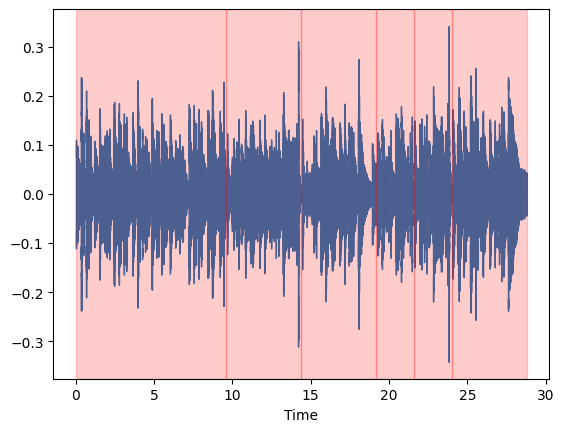

In [7]:
guitar_players = ['00', '01', '02', '03', '04', '05']
genres = ['BN', 'Funk', 'Jazz', 'Rock', 'SS']
song_numbers = [1, 2, 3]
guitar_styles = ['comp', 'solo']
song_bpm_keys = {
    'BN1': ['129-Eb', '147-Gb'],
    'BN2': ['131-B', '166-Ab'],
    'BN3': ['119-G', '154-E'],
    'Funk1': ['97-C', '114-Ab'],
    'Funk2': ['108-Eb', '119-G'],
    'Funk3': ['112-C#', '98-A'],
    'Jazz1': ['130-D', '200-B'],
    'Jazz2': ['110-Bb', '187-F#'],
    'Jazz3': ['150-C', '137-Eb'],
    'Rock1': ['90-C#', '130-A'],
    'Rock2': ['85-F', '142-D'],
    'Rock3': ['148-C', '117-Bb'],
    'SS1': ['68-E', '100-C#'],
    'SS2': ['88-F', '107-Ab'],
    'SS3': ['98-C', '84-Bb'],
}


guitar_player = guitar_players[4] # 0: 00, 1: 01, 2: 02, 3: 03, 4: 04, 5: 05
genre = genres[4]                 # 0: BN, 1: Funk, 2: Jazz, 3: Rock, 4: SS
song_number = song_numbers[0]     # 0: 1 // 1: 2 // 2: 3
guitar_style = guitar_styles[0]   # 0: comp, 1: solo


name_file = fr"{guitar_player}_{genre}{song_number}-{song_bpm_keys[f'{genre}{song_number}'][1]}_{guitar_style}"
print(f'File analyzed: {name_file}')

root = r"C:\Users\Luis\Desktop\Master\DSAP\chord-detection-project\guitarset"
#jam_file = glob.glob(f"{root}/{name_file}.jams")[0]

jam = jams.load(f"{root}/annotation/{name_file}.jams")

# 1) look at available namespaces
print([ann.namespace for ann in jam.annotations])

# 2) extract primary chord annotation
chords = jam.search(namespace='chord')[0]        # first annotator
df = chords.to_dataframe()[['time', 'duration', 'value']]
print(df)

# 3) listen to a 30-s excerpt while seeing chords
wav = f"{root}/audio_mono-mic/{name_file}_mic.wav"
y, sr = librosa.load(wav, sr=None)
librosa.display.waveshow(y[:30*sr], sr=sr)
for _, row in df[df.time < 30].iterrows():
    plt.axvspan(row.time, row.time+row.duration, color='red', alpha=.2)
plt.show()

# Inspect all the chords from the dataset

In [4]:
# Root directory for annotations
root = Path("/kaggle/input/guitarset")
annotation_dir = root / "annotation"

def remove_inversion(chord_label: str) -> str:
    """Remove inversion from chord label (e.g., 'C:maj/3' -> 'C:maj')"""
    if chord_label == "N":  # No chord
        return chord_label
    # Remove the inversion part (after '/')
    return chord_label.split("/")[0]

# Count all chords across all annotation files
chord_counter = Counter()

# Iterate through all JAMS files
jam_files = sorted(annotation_dir.glob("*.jams"))
print(f"Found {len(jam_files)} annotation files\n")

for jam_path in jam_files:
    # Skip solo files
    if not jam_path.stem.endswith("_comp"):
        continue
    jam = jams.load(str(jam_path))
    chord_anns = jam.search(namespace="chord")
    
    if not chord_anns:
        continue
    
    # Use first annotator
    for event in chord_anns[0].data:
        chord_label = event.value
        # Normalize by removing inversions
        normalized = remove_inversion(chord_label)
        chord_counter[normalized] += 1

# Display results sorted by frequency (most common first)
print(f"{'='*60}")
print(f"TOTAL UNIQUE CHORDS (ignoring inversions): {len(chord_counter)}")
print(f"{'='*60}\n")

print(f"{'Chord':<20} {'Count':>10}")
print(f"{'-'*30}")

for chord, count in chord_counter.most_common():
    print(f"{chord:<20} {count:>10}")

print(f"\n{'='*60}")
print(f"TOTAL CHORD OCCURRENCES: {sum(chord_counter.values())}")
print(f"{'='*60}")


Found 360 annotation files

TOTAL UNIQUE CHORDS (ignoring inversions): 42

Chord                     Count
------------------------------
F:maj                       144
G:maj                       126
G#:maj                      114
C#:maj                      114
C:maj                       114
D#:maj                      108
E:maj                       108
A#:maj                      102
D:maj                       102
F#:maj                       96
B:maj                        96
A:maj                        96
E:min                        60
G:min                        60
C#:min                       48
D#:7                         48
G#:min                       48
A#:min                       48
F#:7                         36
B:min                        36
F:min                        36
A:min                        36
C:7                          36
D:min                        36
A:7                          24
A#:hdim7                     24
C#:7                         2

In [5]:
# Chromatic order of root notes
CHROMATIC_ROOTS = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

def parse_chord(chord_label: str):
    """Parse chord into (root, quality). Returns (None, None) for 'N' or invalid."""
    if chord_label == "N" or ":" not in chord_label:
        return None, None
    root, quality = chord_label.split(":", 1)
    return root, quality

# Organize by root note
root_counts = defaultdict(lambda: {"maj": 0, "min": 0, "other": 0})

for chord, count in chord_counter.items():
    root, quality = parse_chord(chord)
    if root is None:
        continue
    
    # Categorize by quality
    if quality == "maj":
        root_counts[root]["maj"] += count
    elif quality == "min":
        root_counts[root]["min"] += count
    else:
        root_counts[root]["other"] += count

# Display in chromatic order
print(f"{'='*70}")
print(f"CHORD COUNTS BY ROOT NOTE (Major / Minor / Other)")
print(f"{'='*70}\n")

print(f"{'Root':<6} {'Major':>10} {'Minor':>10} {'Other':>10} {'Total':>10}")
print(f"{'-'*50}")

grand_total_maj = 0
grand_total_min = 0
grand_total_other = 0

for root in CHROMATIC_ROOTS:
    counts = root_counts[root]
    maj = counts["maj"]
    min_ = counts["min"]
    other = counts["other"]
    total = maj + min_ + other
    
    grand_total_maj += maj
    grand_total_min += min_
    grand_total_other += other
    
    print(f"{root:<6} {maj:>10} {min_:>10} {other:>10} {total:>10}")

print(f"{'-'*50}")
print(f"{'TOTAL':<6} {grand_total_maj:>10} {grand_total_min:>10} {grand_total_other:>10} {grand_total_maj + grand_total_min + grand_total_other:>10}")
print(f"\n{'='*70}")


CHORD COUNTS BY ROOT NOTE (Major / Minor / Other)

Root        Major      Minor      Other      Total
--------------------------------------------------
C             114         24         48        186
C#            114         48         36        198
D             102         36         12        150
D#            108         24         48        180
E             108         60         24        192
F             144         36         36        216
F#             96         24         36        156
G             126         60         24        210
G#            114         48         24        186
A              96         36         36        168
A#            102         48         36        186
B              96         36          0        132
--------------------------------------------------
TOTAL        1320        480        360       2160



In [6]:
# Count files in the chords directory by root note (Major / Minor)
from pathlib import Path

# Chromatic order of root notes
CHROMATIC_ROOTS = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

# Path to the chords directory
chords_root = Path("../chords")
splits = ["test"]

def count_files_in_chord_dir(chord_dir: Path) -> int:
    """Count number of wav files in a chord directory across all splits."""
    total = 0
    for split in splits:
        split_chord_dir = chord_dir.parent.parent / split / chord_dir.name
        if split_chord_dir.exists():
            total += len(list(split_chord_dir.glob("*.wav")))
    return total

# Count files for each chord class
root_counts = {root: {"maj": 0, "min": 0} for root in CHROMATIC_ROOTS}

for root in CHROMATIC_ROOTS:
    # Major chord folder (just the root name, e.g., "C")
    for split in splits:
        maj_dir = chords_root / split / root
        if maj_dir.exists():
            root_counts[root]["maj"] += len(list(maj_dir.glob("*.wav")))
    
    # Minor chord folder (root + "m", e.g., "Cm")
    for split in splits:
        min_dir = chords_root / split / f"{root}m"
        if min_dir.exists():
            root_counts[root]["min"] += len(list(min_dir.glob("*.wav")))

# Display results
print(f"{'='*70}")
print(f"{splits[0]} partition")
print(f"{'='*70}\n")

print(f"{'Root':<6} {'Major':>10} {'Minor':>10}")
print(f"{'-'*40}")

grand_total_maj = 0
grand_total_min = 0

for root in CHROMATIC_ROOTS:
    maj = root_counts[root]["maj"]
    min_ = root_counts[root]["min"]
    total = maj + min_
    
    grand_total_maj += maj
    grand_total_min += min_
    
    print(f"{root:<6} {maj:>10} {min_:>10}")

print(f"{'-'*40}")
print(f"{'TOTAL':<6} {grand_total_maj:>10} {grand_total_min:>10}")
print(f"\n{'='*70}")


test partition

Root        Major      Minor
----------------------------------------
C              12          5
C#             12          8
D              11          9
D#             12          8
E              12          9
F              15         15
F#             11          6
G              14         12
G#             12         12
A              11          6
A#             11         12
B              11          8
----------------------------------------
TOTAL         144        110



# Inspect the final data partitions from the processed dataset

In [ ]:
# Load the snippet summary
summary_path = Path("/kaggle/input/guitarset-chord-recognition/chords/snippet_summary.json")
with open(summary_path, "r") as f:
    summary = json.load(f)

# Build the DataFrame
rows = []
for chord in summary["train"].keys():
    rows.append({
        "chord": chord,
        "count": summary["train"][chord]["count"],
        #"train_duration": round(summary["train"][chord]["seconds"], 2),
        #"val_examples": summary["val"][chord]["count"],
        #"val_duration": round(summary["val"][chord]["seconds"], 2),
        #"test_examples": summary["test"][chord]["count"],
        #"test_duration": round(summary["test"][chord]["seconds"], 2),
    })

df_summary = pd.DataFrame(rows)

# Add total row
totals = {
    "chord": "TOTAL",
    "train_examples": df_summary["train_examples"].sum(),
    "train_duration": round(df_summary["train_duration"].sum(), 2),
    "val_examples": df_summary["val_examples"].sum(),
    "val_duration": round(df_summary["val_duration"].sum(), 2),
    "test_examples": df_summary["test_examples"].sum(),
    "test_duration": round(df_summary["test_duration"].sum(), 2),
}
df_summary = pd.concat([df_summary, pd.DataFrame([totals])], ignore_index=True)

# Display
print("Extracted Snippets Summary (Train/Val/Test Split)")
print("=" * 90)
df_summary[['chord','train_examples', 'train_duration']]


Extracted Snippets Summary (Train/Val/Test Split)


,chord,train_examples,train_duration
0,C,91,244.57
1,Cm,19,35.93
2,C#,91,342.41
3,C#m,38,74.05
4,D,81,208.14
5,Dm,28,77.17
6,D#,86,233.87
7,D#m,19,66.30
8,E,86,252.73
9,Em,48,90.70


In [7]:
df_summary[['chord','val_examples', 'val_duration']]


,chord,val_examples,val_duration
0,C,11,32.25
1,Cm,2,3.77
2,C#,11,41.67
3,C#m,4,6.69
4,D,10,27.41
5,Dm,3,9.62
6,D#,10,24.34
7,D#m,2,4.36
8,E,10,52.56
9,Em,6,12.61


In [8]:
df_summary[['chord','test_examples', 'test_duration']]


,chord,test_examples,test_duration
0,C,12,26.43
1,Cm,3,5.52
2,C#,12,51.03
3,C#m,6,11.61
4,D,11,30.79
5,Dm,5,12.67
6,D#,12,27.77
7,D#m,3,8.81
8,E,12,37.17
9,Em,6,10.92


# Duration Statistics Analysis

In [11]:
DATASET_ROOT = Path('/kaggle/input/guitarset')
ANNOTATION_DIR = DATASET_ROOT / "annotation"
AUDIO_DIR = DATASET_ROOT / "audio_mono-mic"
OUTPUT_ROOT = Path('/kaggle/working/') / "chords"

# All 12 chromatic roots
CHROMATIC_ROOTS = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

# Target chords → output folder name mapping
# Each key is a (root, quality) pair as used in Harte notation
# We include all 12 roots for both major and minor chords (24 classes total)
TARGET_CHORDS: Dict[Tuple[str, str], str] = {}
for root in CHROMATIC_ROOTS:
    TARGET_CHORDS[(root, "maj")] = root           # e.g., ("C", "maj") -> "C"
    TARGET_CHORDS[(root, "min")] = f"{root}m"     # e.g., ("C", "min") -> "Cm"

def _canonicalize(label: str) -> Tuple[str, str]:
    """Return (root, quality) ignoring extensions/inversions.

    Example: "C:maj/3" -> ("C", "maj")
    """
    if label == "N":
        return ("N", "N")

    # Remove inversion (slash chords)
    label = label.split("/")[0]
    try:
        root, extra = label.split(":", 1)
    except ValueError:
        # malformed, treat as non-target
        return ("", "")

    # Remove extensions e.g. "maj7(9)" → "maj7"
    extra = extra.split("(")[0]

    # Strip numerals (maj7 -> maj, min9 -> min)
    extra = extra.rstrip("0123456789")
    return root, extra


def _match_target(label: str):
    """Return True if *label* matches a target chord without extensions.

    Rules:
    • Inversions ("/3") are ignored.
    • Any numeral in the chord quality (e.g., "maj7", "min9", "7") indicates an extension → reject.
    """
    # Remove inversion first to inspect the quality string
    core = label.split("/")[0]
    if ":" not in core:
        return False

    root, qual = core.split(":", 1)
    # Reject if quality contains any digit (extension) before optional parentheses
    if any(ch.isdigit() for ch in qual.split("(")[0]):
        return False

    return _canonicalize(label) in TARGET_CHORDS


In [12]:
def analyze_duration_statistics(snippets_by_chord: Dict[str, List[dict]]) -> pd.DataFrame:
    """Compute duration statistics for each chord class.
    
    Returns a DataFrame with min, max, 25%, 50%, 75%, mean, std for each chord.
    """
    stats_data = []
    
    for chord_name, snippets in snippets_by_chord.items():
        if not snippets:
            continue
        
        durations = [s["duration"] for s in snippets]
        durations_arr = np.array(durations)
        
        stats_data.append({
            "chord": chord_name,
            "count": len(durations),
            "min": np.min(durations_arr),
            "25%": np.percentile(durations_arr, 25),
            "50%": np.percentile(durations_arr, 50),
            "75%": np.percentile(durations_arr, 75),
            "max": np.max(durations_arr),
            "mean": np.mean(durations_arr),
            "std": np.std(durations_arr),
        })
    
    df = pd.DataFrame(stats_data)
    df = df.set_index("chord")
    
    # Sort by chord name
    df = df.sort_index()
    
    return df


def collect_snippets_metadata() -> Dict[str, List[dict]]:
    """Collect snippet metadata from JAMS files (same logic as extract_snippets)."""
    snippets_by_chord: Dict[str, List[dict]] = {name: [] for name in TARGET_CHORDS.values()}
    
    jam_files: List[Path] = sorted(ANNOTATION_DIR.glob("*.jams"))
    
    for jam_path in tqdm(jam_files, desc="Scanning JAMS"):
        stem = jam_path.stem
        
        if not stem.endswith("_comp"):
            continue
        
        wav_path = AUDIO_DIR / f"{stem}_mic.wav"
        if not wav_path.exists():
            continue
        
        jam = jams.load(str(jam_path))
        chord_ann = jam.search(namespace="chord")
        if not chord_ann:
            continue
        
        chord_ann = chord_ann[0]
        data = chord_ann.data
        
        for event in data:
            label = event.value
            if not _match_target(label):
                continue
            root, quality = _canonicalize(label)
            chord_folder = TARGET_CHORDS[(root, quality)]
            
            snippets_by_chord[chord_folder].append({
                "duration": event.duration,
                "start": event.time,
                "end": event.time + event.duration,
            })
    
    return snippets_by_chord


# Collect metadata and analyze
print("Collecting snippet metadata...")
snippets_metadata = collect_snippets_metadata()

print("\n" + "=" * 80)
print("DURATION STATISTICS PER CHORD CLASS (in seconds)")
print("=" * 80)

stats_df = analyze_duration_statistics(snippets_metadata)
pd.set_option('display.float_format', '{:.3f}'.format)
print(stats_df.to_string())

# Also show overall statistics
print("\n" + "=" * 80)
print("OVERALL STATISTICS (all chords combined)")
print("=" * 80)

all_durations = []
for snippets in snippets_metadata.values():
    all_durations.extend([s["duration"] for s in snippets])

all_durations_arr = np.array(all_durations)
print(f"Total snippets: {len(all_durations)}")
print(f"Min:    {np.min(all_durations_arr):.3f}s")
print(f"25%:    {np.percentile(all_durations_arr, 25):.3f}s")
print(f"50%:    {np.percentile(all_durations_arr, 50):.3f}s")
print(f"75%:    {np.percentile(all_durations_arr, 75):.3f}s")
print(f"Max:    {np.max(all_durations_arr):.3f}s")
print(f"Mean:   {np.mean(all_durations_arr):.3f}s")
print(f"Std:    {np.std(all_durations_arr):.3f}s")

Scanning JAMS: 100%|██████████| 360/360 [02:08<00:00,  2.80it/s]


DURATION STATISTICS PER CHORD CLASS (in seconds)
       count   min   25%   50%   75%    max  mean   std
chord                                                  
A         96 1.283 1.558 2.449 3.568  7.385 2.862 1.826
A#       102 1.690 1.752 2.017 2.051  2.857 2.112 0.434
A#m       48 2.143 2.581 2.775 3.207  4.364 3.014 0.820
Am        36 1.600 1.600 1.622 2.449  2.449 1.890 0.395
B         96 1.446 1.558 2.222 2.400  4.800 2.255 0.895
Bm        36 1.283 1.283 2.017 3.658  3.664 2.320 0.994
C        114 1.600 1.622 2.017 2.449  9.897 2.660 1.967
C#       114 1.633 2.143 2.727 4.800 10.667 3.817 2.467
C#m       48 1.446 1.530 1.901 2.294  2.449 1.924 0.430
Cm        24 1.752 1.752 1.884 2.017  2.017 1.884 0.132
D        102 1.283 1.846 2.017 2.449  7.385 2.611 1.396
D#       108 1.752 2.017 2.051 2.857  7.442 2.648 1.316
D#m       24 2.182 2.182 3.310 4.439  4.444 3.311 1.130
Dm        36 2.051 2.051 2.857 3.380  3.380 2.763 0.547
E        108 1.200 1.558 2.243 2.449 14.118 3.171 3.13

In [ ]:
# Compare augmentation impact for different window sizes
def simulate_augmentation(snippets_by_chord: Dict[str, List[dict]], 
                          window_size: float, 
                          threshold: int = 90) -> Dict[str, int]:
    """Simulate how many examples we'd get with a given window size."""
    results = {}
    
    for chord_name, snippets in snippets_by_chord.items():
        original_count = len(snippets)
        
        if original_count >= threshold:
            # Well-represented: no augmentation
            results[chord_name] = original_count
            continue
        
        # Under-represented: count windows
        total_windows = 0
        for snippet in snippets:
            duration = snippet["duration"]
            num_windows = max(1, int(duration // window_size))
            total_windows += num_windows
        
        results[chord_name] = total_windows
    
    return results

# Simulate for different window sizes
window_sizes = [2.0, 1.5, 1.0]
print("=" * 80)
print("AUGMENTATION COMPARISON: Different Window Sizes")
print("=" * 80)
print(f"\n{'Chord':<6} {'Original':>10} " + " ".join([f"{ws}s window" for ws in window_sizes]))
print("-" * 60)

under_rep_chords = [name for name, snips in snippets_metadata.items() if len(snips) < 90]

for chord_name in sorted(under_rep_chords):
    original = len(snippets_metadata[chord_name])
    row = f"{chord_name:<6} {original:>10}"
    
    for ws in window_sizes:
        results = simulate_augmentation(snippets_metadata, ws, threshold=90)
        row += f" {results[chord_name]:>10}"
    
    print(row)

# Summary totals
print("-" * 60)
print("TOTALS (under-represented only):")
for ws in window_sizes:
    results = simulate_augmentation(snippets_metadata, ws, threshold=90)
    total = sum(results[c] for c in under_rep_chords)
    original_total = sum(len(snippets_metadata[c]) for c in under_rep_chords)
    print(f"  {ws}s windows: {total} examples (was {original_total}, +{total - original_total})")


AUGMENTATION COMPARISON: Different Window Sizes

Chord    Original 2.0s window 1.5s window 1.0s window
------------------------------------------------------------
A#m            48         60         60        120
Am             36         36         36         48
Bm             36         36         48         72
C#m            48         48         48         72
Cm             24         24         24         36
D#m            24         36         36         72
Dm             36         36         48         84
Em             60         60         60         84
F#m            24         24         24         48
Fm             36         60         84        144
G#m            48         60         60        108
Gm             60         72         72        120
------------------------------------------------------------
TOTALS (under-represented only):
  2.0s windows: 552 examples (was 480, +72)
  1.5s windows: 600 examples (was 480, +120)
  1.0s windows: 1008 examples (was 480, +

# Extract Chord Progressions for All Accompaniment Pieces

Extract a list of chord progressions for each of the 180 accompaniment files (ending with `_comp`).


In [5]:
# Root directory for annotations
annotation_dir = Path('/kaggle/input/guitarset/annotation')

def extract_chord_progression(jam_path: Path) -> List[str]:
    """Extract chord progression from a JAMS file.
    
    Returns a list of chord labels (strings).
    """
    jam = jams.load(str(jam_path))
    chord_anns = jam.search(namespace="chord")
    
    if not chord_anns:
        return []
    
    return [event.value for event in chord_anns[0].data]

# Collect chord progressions as a list of lists
chord_progressions = []

# Get all _comp.jams files
comp_files = sorted([f for f in annotation_dir.glob("*.jams") if f.stem.endswith("_comp")])
print(f"Found {len(comp_files)} accompaniment files\n")

for jam_path in comp_files:
    progression = extract_chord_progression(jam_path)
    chord_progressions.append(progression)

# Display summary
print(f"Extracted {len(chord_progressions)} chord progressions")
print(f"Type: list of {len(chord_progressions)} lists")
print(f"\nFirst 5 progressions:")
for i, prog in enumerate(chord_progressions[:5]):
    print(f"  [{i}]: {prog}")


Found 180 accompaniment files

Extracted 180 chord progressions
Type: list of 180 lists

First 5 progressions:
  [0]: ['D#:maj', 'G#:maj', 'D#:maj', 'A#:maj', 'G#:maj', 'D#:maj']
  [1]: ['F#:maj', 'B:maj', 'F#:maj', 'C#:maj', 'B:maj', 'F#:maj']
  [2]: ['E:min', 'A:7', 'D:maj', 'G:maj', 'C#:hdim7', 'F#:7', 'B:min', 'E:min', 'A:7', 'D:maj', 'G:maj', 'C#:hdim7', 'F#:7', 'B:min']
  [3]: ['C#:min', 'F#:7', 'B:maj', 'E:maj', 'A#:hdim7', 'D#:7', 'G#:min', 'C#:min', 'F#:7', 'B:maj', 'E:maj', 'A#:hdim7', 'D#:7', 'G#:min']
  [4]: ['G:maj', 'D:maj', 'E:min', 'B:min', 'C:maj', 'G:maj', 'C:maj', 'D:maj', 'G:maj', 'D:maj', 'E:min', 'B:min', 'C:maj', 'G:maj', 'C:maj', 'D:maj']


In [7]:
# Display all 180 chord progressions
print(f"All {len(chord_progressions)} Chord Progressions")
print("=" * 100)

for i, progression in enumerate(chord_progressions):
    chord_seq = " → ".join(progression)
    print(f"\n[{i:3d}] ({len(progression):2d} chords): {chord_seq}")


All 180 Chord Progressions

[  0] ( 6 chords): D#:maj → G#:maj → D#:maj → A#:maj → G#:maj → D#:maj

[  1] ( 6 chords): F#:maj → B:maj → F#:maj → C#:maj → B:maj → F#:maj

[  2] (14 chords): E:min → A:7 → D:maj → G:maj → C#:hdim7 → F#:7 → B:min → E:min → A:7 → D:maj → G:maj → C#:hdim7 → F#:7 → B:min

[  3] (14 chords): C#:min → F#:7 → B:maj → E:maj → A#:hdim7 → D#:7 → G#:min → C#:min → F#:7 → B:maj → E:maj → A#:hdim7 → D#:7 → G#:min

[  4] (16 chords): G:maj → D:maj → E:min → B:min → C:maj → G:maj → C:maj → D:maj → G:maj → D:maj → E:min → B:min → C:maj → G:maj → C:maj → D:maj

[  5] (16 chords): E:maj → B:maj → C#:min → G#:min → A:maj → E:maj → A:maj → B:maj → E:maj → B:maj → C#:min → G#:min → A:maj → E:maj → A:maj → B:maj

[  6] ( 6 chords): G#:maj → C#:maj → G#:maj → D#:maj → C#:maj → G#:maj

[  7] ( 6 chords): C:maj → F:maj → C:maj → G:maj → F:maj → C:maj

[  8] (14 chords): G#:min → C#:7 → F#:maj → B:maj → F:hdim7 → A#:7 → D#:min → G#:min → C#:7 → F#:maj → B:maj → F:hdim7 → A#:7 → D#

In [ ]:
# Standardize chord labels to match the 24 classes (12 major + 12 minor)
def standardize_chord(chord_label: str) -> str:
    """Convert chord label to standardized format.
    
    Rules:
    - Major chords (X:maj) → X (root only)
    - Minor chords (X:min) → Xm
    - Seventh chords (X:7) → X (treated as major)
    - Half-diminished 7th (X:hdim7) → Xm (treated as minor)
    - Inversions (/N) are ignored
    """
    # Remove inversion if present
    chord_label = chord_label.split("/")[0]
    
    if ":" not in chord_label:
        return chord_label  # Return as-is if malformed
    
    root, quality = chord_label.split(":", 1)
    
    # Map quality to standardized format
    if quality == "maj":
        return root  # Major → just root
    elif quality == "min":
        return f"{root}m"  # Minor → root + "m"
    elif quality == "7":
        return root  # Dominant 7th → major (just root)
    elif quality == "hdim7":
        return f"{root}m"  # Half-diminished → minor
    else:
        # Default: treat unknown as major
        return root

# Apply standardization to all progressions
chord_progressions_std = [
    [standardize_chord(c) for c in prog] 
    for prog in chord_progressions
]

# Display first 5 standardized progressions
print("Standardized Chord Progressions (first 5):")
print("=" * 80)
for i, prog in enumerate(chord_progressions_std[:5]):
    print(f"  [{i}]: {prog}")


Progression length stats:
  Min: 6 chords
  Max: 16 chords
  Avg: 12.0 chords


In [ ]:
# Display all 180 standardized chord progressions
print(f"All {len(chord_progressions_std)} Standardized Chord Progressions")
print("=" * 100)

for i, progression in enumerate(chord_progressions_std):
    chord_seq = " → ".join(progression)
    print(f"\n[{i:3d}] ({len(progression):2d} chords): {chord_seq}")


In [ ]:
# Verify all chords match the 24 valid classes
VALID_CHORDS = {
    "C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B",  # Major
    "Cm", "C#m", "Dm", "D#m", "Em", "Fm", "F#m", "Gm", "G#m", "Am", "A#m", "Bm"  # Minor
}

# Collect all unique chords used in progressions
all_chords_used = set()
for prog in chord_progressions_std:
    all_chords_used.update(prog)

# Check for invalid chords
invalid_chords = all_chords_used - VALID_CHORDS
valid_chords_used = all_chords_used & VALID_CHORDS

print(f"Validation Results:")
print(f"  Valid chord classes used: {len(valid_chords_used)}/{len(VALID_CHORDS)}")
print(f"  Chords used: {sorted(valid_chords_used)}")

if invalid_chords:
    print(f"\n  ⚠️ Invalid chords found: {invalid_chords}")
else:
    print(f"\n  ✓ All chords are valid!")
